In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from corus import load_lenta
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, NMF, LatentDirichletAllocation
from sklearn.manifold import TSNE
from bertopic import BERTopic
import nltk

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Загрузка стоп-слов для русского языка
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
russian_stop = stopwords.words('russian')

In [3]:
# Загрузка документов 
# Загружаем первые N статей из Lenta-corpus
LENTA_PATH = '/Users/juliak/PycharmProjects/MSP/TM/lenta-ru-news.csv.gz'
def load_docs(path: str, limit: int = 2000):
    docs = []
    for i, record in enumerate(load_lenta(path)):
        if i >= limit:
            break
        docs.append(record.text)
    return docs

In [4]:
# Векторизация 
# TF-IDF для LSA и NMF
# max_df=0.9 - игнорировать термины, встречающиеся в >90% документов
# min_df=10 - только термины, которые встречаются как минимум в 10 документах
vectorizer_tfidf = TfidfVectorizer(max_df=0.9, min_df=10, stop_words=russian_stop)
# CountVectorizer для LDA
vectorizer_count = CountVectorizer(max_df=0.9, min_df=10, stop_words=russian_stop)

Обучение моделей 

LSA (Latent Semantic Analysis) — метод снижения размерности и выявления скрытых семантических связей. Применяется для анализа скрытой структуры в тексте и уменьшения шумов.


In [ ]:
def train_lsa(docs, n_topics=10):
    """
    Обучает TruncatedSVD (LSA) на TF-IDF представлении.
    Возвращает модель и матрицу эмбеддингов документов (shape=(n_docs, n_topics)).
    """
    X = vectorizer_tfidf.fit_transform(docs)
    model = TruncatedSVD(n_components=n_topics, random_state=42)
    model.fit(X)
    doc_embeddings = model.transform(X)
    return model, doc_embeddings

LDA (Latent Dirichlet Allocation) — вероятностная тематическая модель. Каждый документ считается смесью скрытых тем, каждая тема — распределением слов.

In [ ]:
def train_lda(docs, n_topics=10):
    """
    Обучает LatentDirichletAllocation на CountVectorizer представлении.
    Возвращает модель и матрицу тематических распределений документов.
    """
    X = vectorizer_count.fit_transform(docs)
    model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    model.fit(X)
    doc_dist = model.transform(X)
    return model, doc_dist

NMF (Негативная матричная факторизация) — Раскладывает неотрицательную матрицу TF-IDF на две неотрицательные матрицы: W (термы × темы) и H (темы × документы).

In [ ]:
def train_nmf(docs, n_topics=10):
    """
    Обучает NMF на TF-IDF представлении.
    Возвращает модель и матрицу тематических представлений документов.
    """
    X = vectorizer_tfidf.fit_transform(docs)
    model = NMF(n_components=n_topics, random_state=42)
    model.fit(X)
    doc_dist = model.transform(X)
    return model, doc_dist

BERTopic сочетает трансформерные эмбеддинги и классические алгоритмы кластеризации.

In [5]:
def train_bertopic(docs, n_topics=10):
    """
    Обучает BERTopic с вычислением вероятностей тем.
    Возвращает:
        model: обученная модель BERTopic
        topics: метки тем для каждого документа (list[int])
        probs: массив вероятностей (shape=(n_docs, n_topics))
    """
    # Создаём векторизатор мешка слов с базовыми настройками
    vectorizer = CountVectorizer(
        max_df=0.9, # игнорировать слова, встречающиеся в >90% документов
        min_df=1, # учитывать слова, встречающиеся минимум в 1 документе
        stop_words=russian_stop # использовать список русских стоп-слов
    )
    # Инициализируем модель BERTopic
    model = BERTopic(
        nr_topics=n_topics, # число тем
        vectorizer_model=vectorizer, # передаём кастомный CountVectorizer
        language=None, # язык корпуса (None — автоопределение)
        verbose=False, # отключаем подробный вывод лога
        calculate_probabilities=True # включаем вычисление вероятностей тем для документов
    )
    # Обучаем модель и сразу получаем метки тем и матрицу вероятностей (n_docs × n_topics)
    topics, probs = model.fit_transform(docs)
    # Возвращаем обученную модель, метки тем и вероятности
    return model, topics, probs


In [6]:
# Визуализация топ-слов для тем (LSA, LDA, NMF) 
def plot_top_words(model, feature_names, n_top_words=8, title=''):
    if not hasattr(model, 'components_'):
        print("Model has no attribute `components_` — cannot plot top words.")
        return
    n_topics = model.components_.shape[0]
    fig, axes = plt.subplots(1, n_topics, figsize=(2*n_topics, 6), sharex=False)
    for idx, comp in enumerate(model.components_):
        top_idx = np.argsort(comp)[-n_top_words:]
        words = [feature_names[i] for i in top_idx]
        weights = comp[top_idx]
        ax = axes[idx]
        ax.barh(words, weights)
        ax.set_title(f"Topic {idx}")
        ax.invert_yaxis()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [7]:
# t-SNE визуализация 
def plot_tsne(embeddings, labels, title='t-SNE visualization'):
    """
    Строит двумерную t-SNE проекцию эмбеддингов и раскрашивает их по темам.
    """
    # Шаг 1: проверка размерности
    if embeddings.ndim == 1:
        embeddings = embeddings.reshape(-1, 1)
    # Шаг 2: инициализация TSNE
    tsne = TSNE(n_components=2, random_state=42)
    # Шаг 3: вычисляем двумерную проекцию
    coords = tsne.fit_transform(embeddings)
    # Шаг 4: рисуем точки
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], # X и Y координаты
                          c=labels, # цвет по теме
                          cmap='tab10', # палитра для категориальных значений
                          alpha=0.6 # прозрачность
                          )
    # Шаг 5: легенда
    plt.legend(*scatter.legend_elements(), title="Topics")
    # Шаг 6: заголовок и отображение
    plt.title(title)
    plt.show()

In [8]:
# Запуск и визуализация 
if __name__ == '__main__':
    docs = load_docs(LENTA_PATH, limit=2000)

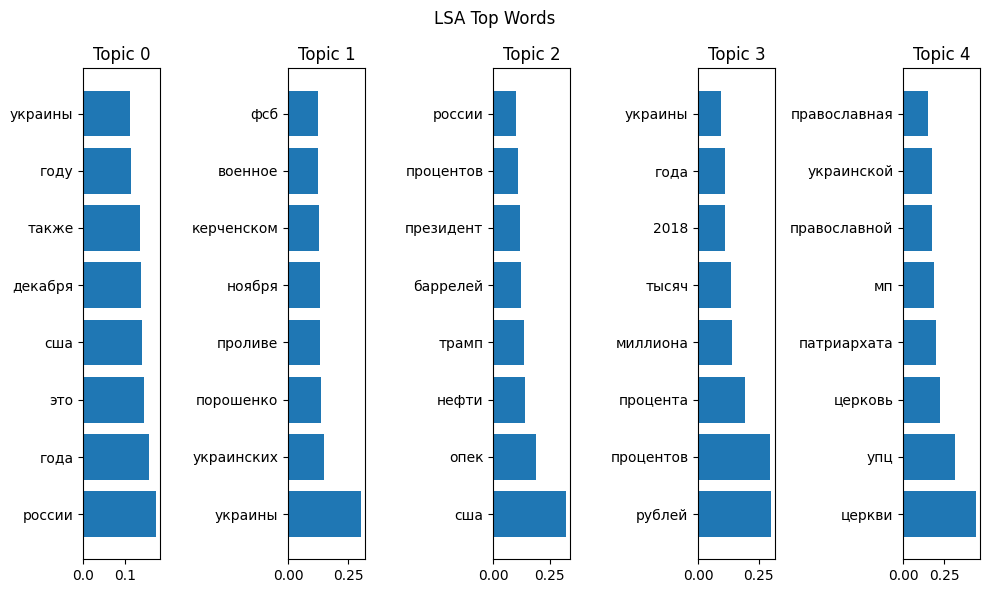

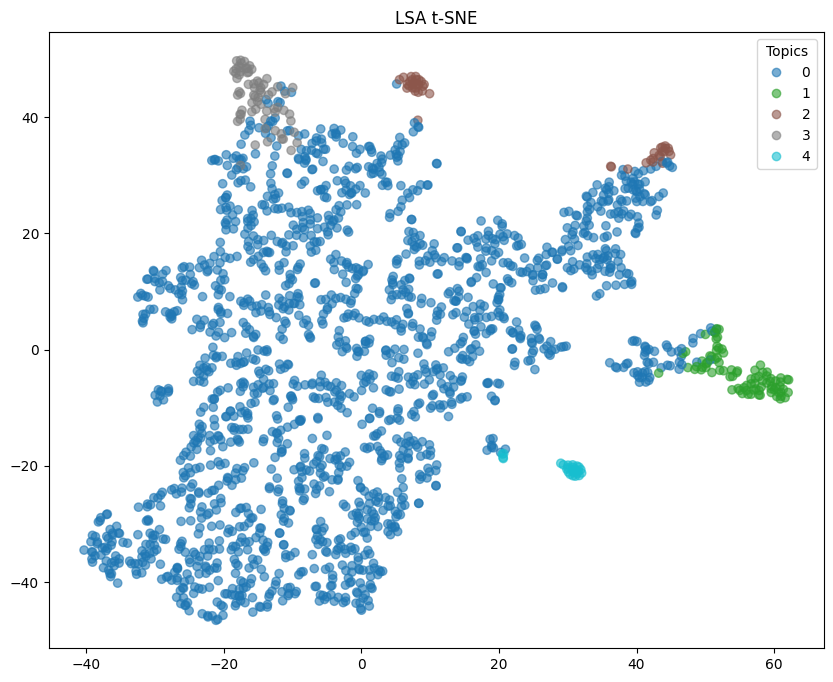

In [9]:
    # LSA
    lsa_model, lsa_emb = train_lsa(docs, n_topics=5)
    plot_top_words(lsa_model, vectorizer_tfidf.get_feature_names_out(), title='LSA Top Words')
    plot_tsne(lsa_emb, np.argmax(lsa_emb, axis=1), title='LSA t-SNE')

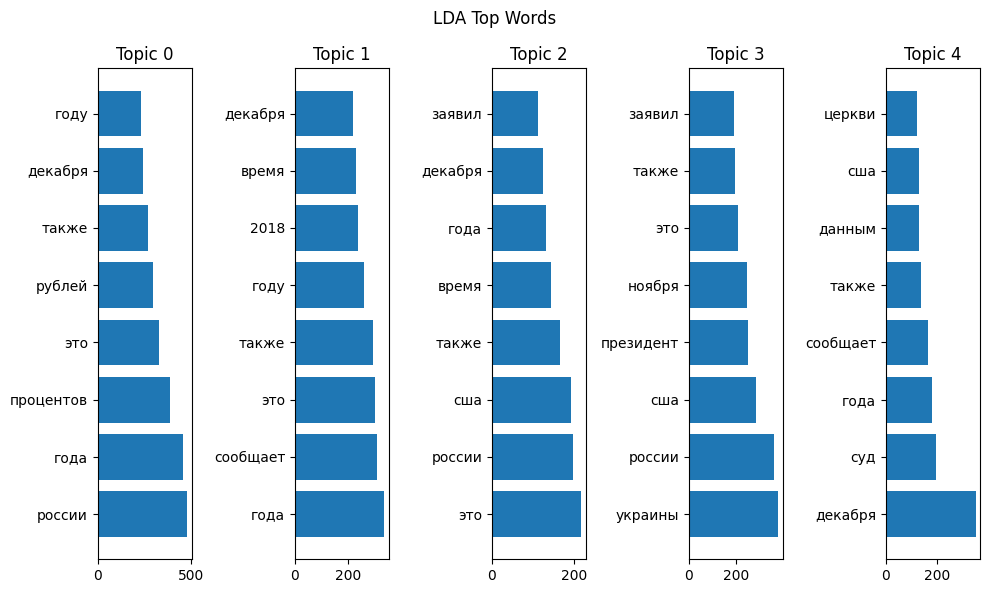

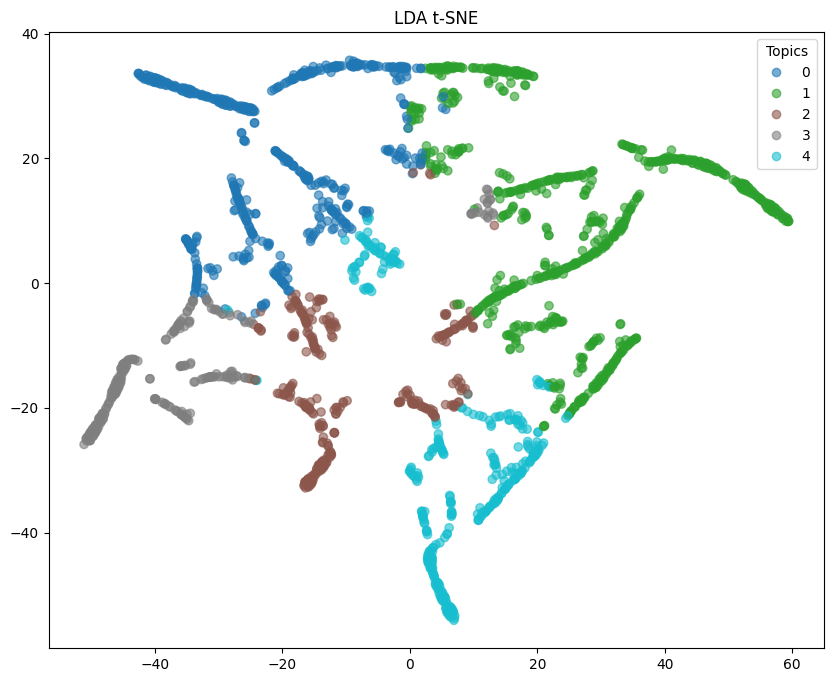

In [10]:
    # LDA
    lda_model, lda_dist = train_lda(docs, n_topics=5)
    plot_top_words(lda_model, vectorizer_count.get_feature_names_out(), title='LDA Top Words')
    plot_tsne(lda_dist, np.argmax(lda_dist, axis=1), title='LDA t-SNE')

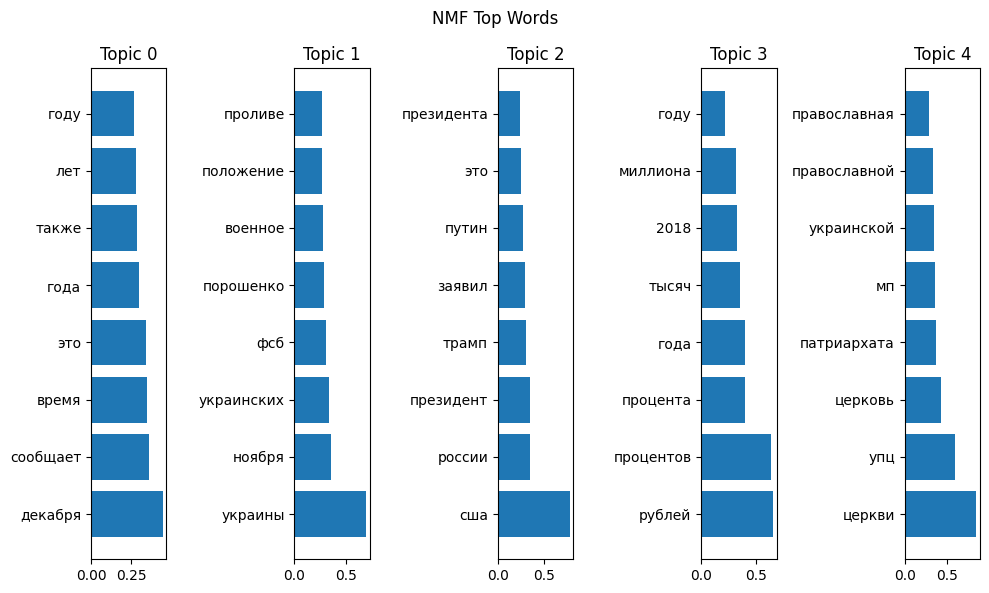

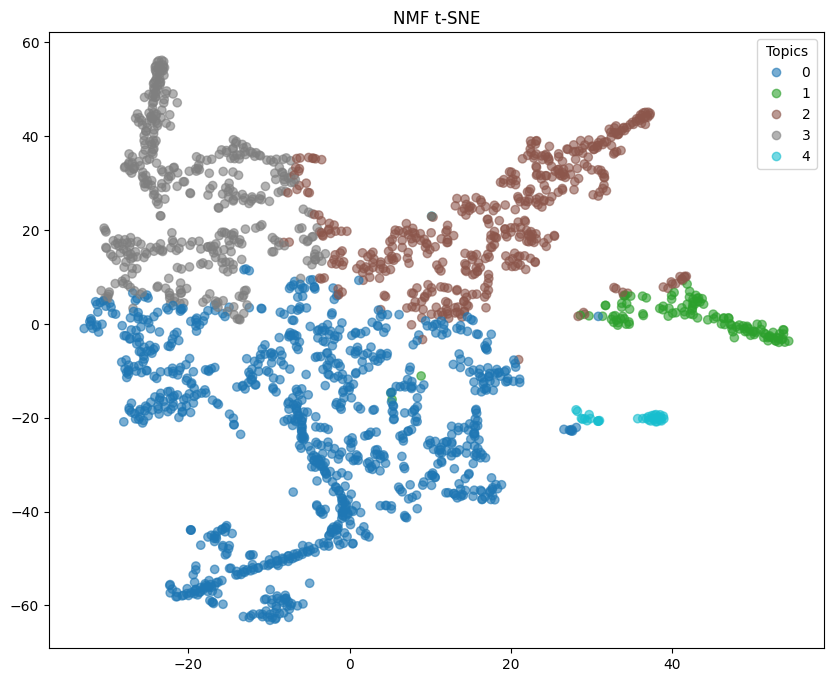

In [11]:
    # NMF
    nmf_model, nmf_dist = train_nmf(docs, n_topics=5)
    plot_top_words(nmf_model, vectorizer_tfidf.get_feature_names_out(), title='NMF Top Words')
    plot_tsne(nmf_dist, np.argmax(nmf_dist, axis=1), title='NMF t-SNE')

Topic 0: south, china, morning, post, юаней
Topic 1: youtube, канале, украины, россии, ноября
Topic 2: mail, daily, авиакомпании, борту, кейт
Topic 3: telegram, канале, telegraph, россии, великобритании
Topic 4: россии, которые, ноября, который, украины


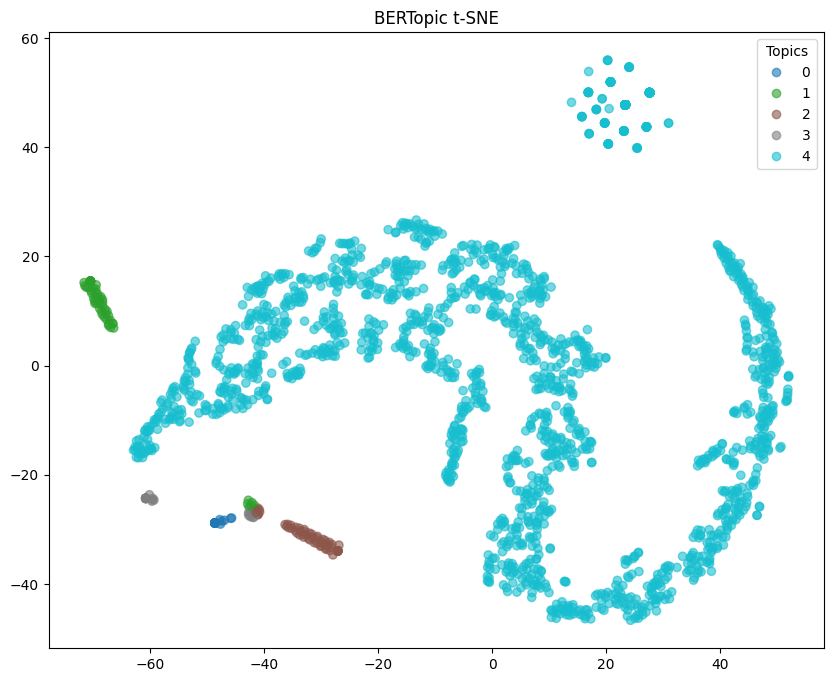

In [12]:
    # BERTopic
    bert_model, bert_topics, bert_emb = train_bertopic(docs, n_topics=5)

    # Выводим топ-5 слов для каждой темы из BERTopic
    topics_dict = bert_model.get_topics()
    for topic_id, word_weights in topics_dict.items():
        top5 = [word for word, weight in word_weights[:5]]
        print(f"Topic {topic_id}: {', '.join(top5)}")

    # Визуализация t-SNE для BERTopic
    plot_tsne(bert_emb, bert_topics, title='BERTopic t-SNE')